# Clustering Experiments

This notebook evaluates different clustering algorithms and cluster counts using the engineered customer feature matrix.

The goal is to identify clustering configurations that produce well-separated, meaningful, and reasonably sized customer segments.

In [1]:
import pandas as pd
import numpy as np

file_path = "../data/processed/customer_features_engineered.csv"

X = pd.read_csv(file_path)

print("Shape:", X.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nMissing values:")
print(X.isna().sum())

display(X.head())

Shape: (5350, 6)

Features:
['Recency', 'Frequency', 'Monetary', 'Total_Quantity', 'Unique_Products', 'Average_Order_Value']

Missing values:
Recency                0
Frequency              0
Monetary               0
Total_Quantity         0
Unique_Products        0
Average_Order_Value    0
dtype: int64


,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,Average_Order_Value
0,0.585878,1.247157,3.263082,3.367144,-0.341731,4.527888
1,0.962177,-1.062694,-0.541386,-0.252142,-0.748955,0.653039
2,1.352766,-0.562340,-0.138545,-0.007263,-0.576507,0.457438
3,1.609982,-1.062694,-0.897479,-1.048445,-0.702308,-0.038367
4,-0.957423,2.149091,1.687025,1.145092,0.574043,0.378653


In [2]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [3]:
from sklearn.cluster import KMeans

kmeans_baseline = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels_baseline = kmeans_baseline.fit_predict(X)

print("K-Means baseline trained.")
print("Number of clusters:", len(np.unique(labels_baseline)))
print("Cluster labels:", np.unique(labels_baseline))

K-Means baseline trained.
Number of clusters: 4
Cluster labels: [0 1 2 3]


In [4]:
silhouette = silhouette_score(X, labels_baseline)
davies_bouldin = davies_bouldin_score(X, labels_baseline)
calinski_harabasz = calinski_harabasz_score(X, labels_baseline)

print("===== K-MEANS BASELINE (K=4) =====")
print(f"Silhouette Score:        {silhouette:.4f}")
print(f"Davies-Bouldin Index:    {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz:.2f}")

===== K-MEANS BASELINE (K=4) =====
Silhouette Score:        0.2669
Davies-Bouldin Index:    1.2144
Calinski-Harabasz Score: 2907.05


In [5]:
results_kmeans = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    results_kmeans.append({
        "K": k,
        "Silhouette": silhouette_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels)
    })

kmeans_results = pd.DataFrame(results_kmeans)

display(kmeans_results.round(4))

,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,0.3632,1.0260,4151.8379
1,3,0.2807,1.1960,3408.8717
2,4,0.2669,1.2144,2907.0499
3,5,0.2431,1.2085,2655.6264
4,6,0.2420,1.2198,2437.7951
5,7,0.2270,1.2404,2287.1289
6,8,0.2262,1.2324,2148.2390
7,9,0.2219,1.2072,2033.4211
8,10,0.2156,1.2359,1936.6360


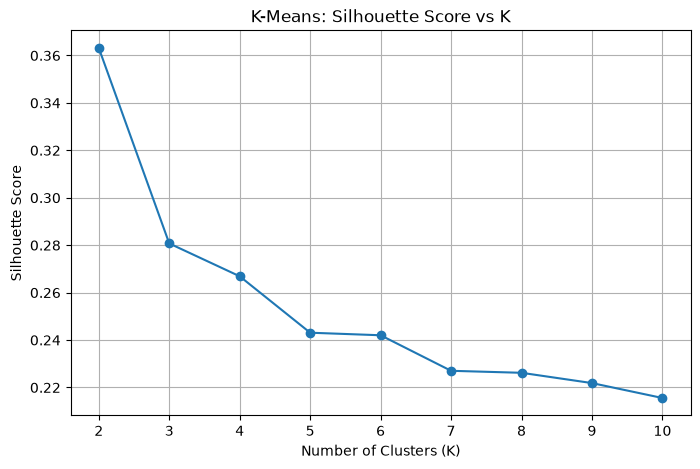

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results["K"],
    kmeans_results["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means: Silhouette Score vs K")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [7]:
cluster_sizes = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    counts = pd.Series(labels).value_counts().sort_index()

    cluster_sizes.append({
        "K": k,
        "Min_Cluster_Size": counts.min(),
        "Max_Cluster_Size": counts.max(),
        "Smallest_Cluster_%": (counts.min() / len(X)) * 100
    })

cluster_sizes_df = pd.DataFrame(cluster_sizes)

display(cluster_sizes_df.round(2))

,K,Min_Cluster_Size,Max_Cluster_Size,Smallest_Cluster_%
0,2,2636,2714,49.27
1,3,1404,2367,26.24
2,4,1012,1897,18.92
3,5,684,1660,12.79
4,6,405,1465,7.57
5,7,331,1190,6.19
6,8,276,1062,5.16
7,9,231,939,4.32
8,10,176,836,3.29


In [8]:
from sklearn.cluster import AgglomerativeClustering

results_agglomerative = []

for k in range(2, 11):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X)

    results_agglomerative.append({
        "K": k,
        "Silhouette": silhouette_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels)
    })

agglomerative_results = pd.DataFrame(results_agglomerative)

display(agglomerative_results.round(4))

,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,0.3455,1.0708,3632.3181
1,3,0.2638,1.0779,2658.3200
2,4,0.1628,1.4108,2195.8551
3,5,0.1448,1.4931,1989.0583
4,6,0.1523,1.5117,1846.3555
5,7,0.1680,1.5312,1776.8031
6,8,0.1707,1.4469,1671.2028
7,9,0.1705,1.3552,1575.8493
8,10,0.1611,1.3313,1500.1587


In [9]:
from sklearn.mixture import GaussianMixture

results_gmm = []

for k in range(2, 11):
    model = GaussianMixture(
        n_components=k,
        random_state=42,
        n_init=5
    )

    labels = model.fit_predict(X)

    results_gmm.append({
        "K": k,
        "Silhouette": silhouette_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels)
    })

gmm_results = pd.DataFrame(results_gmm)

display(gmm_results.round(4))

,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,0.3061,1.1608,3104.3933
1,3,0.1785,1.5290,2291.6284
2,4,0.1080,2.0167,1741.0221
3,5,0.0809,2.1344,1461.5366
4,6,0.0570,3.5104,1029.8559
5,7,0.0195,2.8817,936.8660
6,8,0.0401,3.0685,851.7113
7,9,0.0044,3.3896,741.3361
8,10,-0.0018,3.8459,677.2133


In [10]:
algorithm_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Agglomerative",
        "Gaussian Mixture"
    ],
    "K": [2, 2, 2],
    "Silhouette": [
        kmeans_results.loc[kmeans_results["K"] == 2, "Silhouette"].iloc[0],
        agglomerative_results.loc[agglomerative_results["K"] == 2, "Silhouette"].iloc[0],
        gmm_results.loc[gmm_results["K"] == 2, "Silhouette"].iloc[0]
    ],
    "Davies_Bouldin": [
        kmeans_results.loc[kmeans_results["K"] == 2, "Davies_Bouldin"].iloc[0],
        agglomerative_results.loc[agglomerative_results["K"] == 2, "Davies_Bouldin"].iloc[0],
        gmm_results.loc[gmm_results["K"] == 2, "Davies_Bouldin"].iloc[0]
    ],
    "Calinski_Harabasz": [
        kmeans_results.loc[kmeans_results["K"] == 2, "Calinski_Harabasz"].iloc[0],
        agglomerative_results.loc[agglomerative_results["K"] == 2, "Calinski_Harabasz"].iloc[0],
        gmm_results.loc[gmm_results["K"] == 2, "Calinski_Harabasz"].iloc[0]
    ]
})

display(algorithm_comparison.round(4))

,Algorithm,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,2,0.3632,1.0260,4151.8379
1,Agglomerative,2,0.3455,1.0708,3632.3181
2,Gaussian Mixture,2,0.3061,1.1608,3104.3933


In [11]:
from sklearn.cluster import DBSCAN

dbscan_results = []

for eps in [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]:
    model = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = model.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    if n_clusters >= 2:
        silhouette = silhouette_score(X, labels)
        davies_bouldin = davies_bouldin_score(X, labels)
        calinski_harabasz = calinski_harabasz_score(X, labels)
    else:
        silhouette = np.nan
        davies_bouldin = np.nan
        calinski_harabasz = np.nan

    dbscan_results.append({
        "Epsilon": eps,
        "Clusters": n_clusters,
        "Noise_Points": n_noise,
        "Noise_%": (n_noise / len(X)) * 100,
        "Silhouette": silhouette,
        "Davies_Bouldin": davies_bouldin,
        "Calinski_Harabasz": calinski_harabasz
    })

dbscan_results = pd.DataFrame(dbscan_results)

display(dbscan_results.round(4))

,Epsilon,Clusters,Noise_Points,Noise_%,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,0.3,23,4205,78.5981,-0.5117,1.6046,29.8828
1,0.5,2,1181,22.0748,0.1713,2.9180,804.7482
2,0.7,1,467,8.7290,NaN,NaN,NaN
3,0.9,1,215,4.0187,NaN,NaN,NaN
4,1.1,1,112,2.0935,NaN,NaN,NaN
5,1.3,1,67,1.2523,NaN,NaN,NaN


In [12]:
experiment_summary = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Agglomerative",
        "Gaussian Mixture",
        "DBSCAN"
    ],
    "Configuration": [
        "K=2",
        "K=2",
        "K=2",
        "eps=0.5, min_samples=10"
    ],
    "Silhouette": [
        0.3632,
        0.3455,
        0.3061,
        0.1713
    ],
    "Davies_Bouldin": [
        1.0260,
        1.0708,
        1.1608,
        2.9180
    ],
    "Calinski_Harabasz": [
        4151.84,
        3632.32,
        3104.39,
        804.75
    ]
})

display(experiment_summary)

,Algorithm,Configuration,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,K=2,0.3632,1.0260,4151.84
1,Agglomerative,K=2,0.3455,1.0708,3632.32
2,Gaussian Mixture,K=2,0.3061,1.1608,3104.39
3,DBSCAN,"eps=0.5, min_samples=10",0.1713,2.9180,804.75


In [13]:
best_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

best_labels = best_kmeans.fit_predict(X)

cluster_counts = pd.Series(best_labels).value_counts().sort_index()

print("===== K-MEANS K=2 CLUSTER SIZES =====")
display(cluster_counts.to_frame("Customer_Count"))

print("\nCluster percentages:")
display(
    (cluster_counts / len(X) * 100)
    .round(2)
    .to_frame("Percentage")
)

===== K-MEANS K=2 CLUSTER SIZES =====


,Customer_Count
0,2714
1,2636



Cluster percentages:


,Percentage
0,50.73
1,49.27


### We need the original customer-level features, not the standardized values, because we want interpretable business numbers such as actual spending, orders, quantity, etc.

In [14]:
customer_df = pd.read_csv("../data/processed/customer_features_raw.csv")

customer_clustered = customer_df.copy()
customer_clustered["Cluster"] = best_labels

print("Shape:", customer_clustered.shape)

display(customer_clustered.head())

Shape: (5350, 8)


,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,Average_Order_Value,Cluster
0,12346.0,326,12,77556.46,74285,27,6463.038333,1
1,12608.0,405,1,415.79,323,16,415.790000,0
2,12745.0,487,2,723.85,467,20,361.925000,0
3,12746.0,541,1,254.55,97,17,254.550000,0
4,12747.0,2,26,8898.48,2640,85,342.249231,1


In [15]:
cluster_profile = (
    customer_clustered
    .groupby("Cluster")[[
        "Recency",
        "Frequency",
        "Monetary",
        "Total_Quantity",
        "Unique_Products",
        "Average_Order_Value"
    ]]
    .median()
)

print("===== CLUSTER PROFILES (MEDIAN) =====")

display(cluster_profile.round(2))

===== CLUSTER PROFILES (MEDIAN) =====


,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,Average_Order_Value
Cluster,,,,,,
0,326.0,1.0,334.22,183.5,20.0,197.68
1,37.0,7.0,2182.70,1305.5,101.5,337.72


In [16]:
features_for_profile = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Unique_Products",
    "Average_Order_Value"
]

overall_median = customer_clustered[features_for_profile].median()

cluster_profile_relative = (
    cluster_profile / overall_median
).round(2)

print("===== CLUSTER PROFILE RELATIVE TO OVERALL MEDIAN =====")

display(cluster_profile_relative)

===== CLUSTER PROFILE RELATIVE TO OVERALL MEDIAN =====


,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,Average_Order_Value
Cluster,,,,,,
0,3.31,0.33,0.40,0.40,0.45,0.73
1,0.38,2.33,2.63,2.81,2.31,1.25


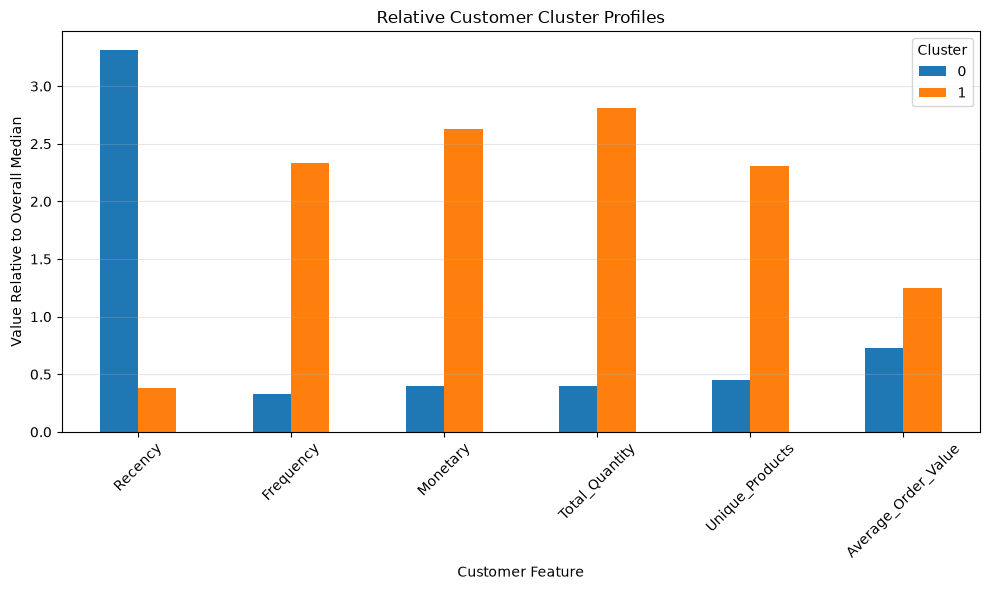

In [17]:
profile_plot = cluster_profile_relative.T

profile_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Relative Customer Cluster Profiles")
plt.xlabel("Customer Feature")
plt.ylabel("Value Relative to Overall Median")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Calculate cluster contribution to total business metrics

cluster_contribution = (
    customer_clustered
    .groupby("Cluster")
    .agg(
        Customers=("Customer ID", "count"),
        Total_Revenue=("Monetary", "sum"),
        Total_Quantity=("Total_Quantity", "sum"),
        Total_Orders=("Frequency", "sum")
    )
)

# Convert totals into percentages
cluster_contribution["Customer_%"] = (
    cluster_contribution["Customers"]
    / cluster_contribution["Customers"].sum()
    * 100
)

cluster_contribution["Revenue_%"] = (
    cluster_contribution["Total_Revenue"]
    / cluster_contribution["Total_Revenue"].sum()
    * 100
)

cluster_contribution["Quantity_%"] = (
    cluster_contribution["Total_Quantity"]
    / cluster_contribution["Total_Quantity"].sum()
    * 100
)

cluster_contribution["Order_%"] = (
    cluster_contribution["Total_Orders"]
    / cluster_contribution["Total_Orders"].sum()
    * 100
)

print("===== CLUSTER BUSINESS CONTRIBUTION =====")

display(
    cluster_contribution.round(2)
)

===== CLUSTER BUSINESS CONTRIBUTION =====


,Customers,Total_Revenue,Total_Quantity,Total_Orders,Customer_%,Revenue_%,Quantity_%,Order_%
Cluster,,,,,,,,
0,2714,1100832.27,620128,5044,50.73,7.65,7.27,15.04
1,2636,13288402.65,7912283,28497,49.27,92.35,92.73,84.96


In [19]:
cluster_value = cluster_contribution.copy()

cluster_value["Revenue_Per_Customer"] = (
    cluster_value["Total_Revenue"]
    / cluster_value["Customers"]
)

cluster_value["Orders_Per_Customer"] = (
    cluster_value["Total_Orders"]
    / cluster_value["Customers"]
)

print("===== CUSTOMER VALUE BY CLUSTER =====")

display(
    cluster_value[
        [
            "Customers",
            "Revenue_Per_Customer",
            "Orders_Per_Customer"
        ]
    ].round(2)
)

===== CUSTOMER VALUE BY CLUSTER =====


,Customers,Revenue_Per_Customer,Orders_Per_Customer
Cluster,,,
0,2714,405.61,1.86
1,2636,5041.12,10.81


In [25]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(X_pca.shape)
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.67300357 0.15462481]

Total explained variance:
(5350, 2)
0.8276283885229946


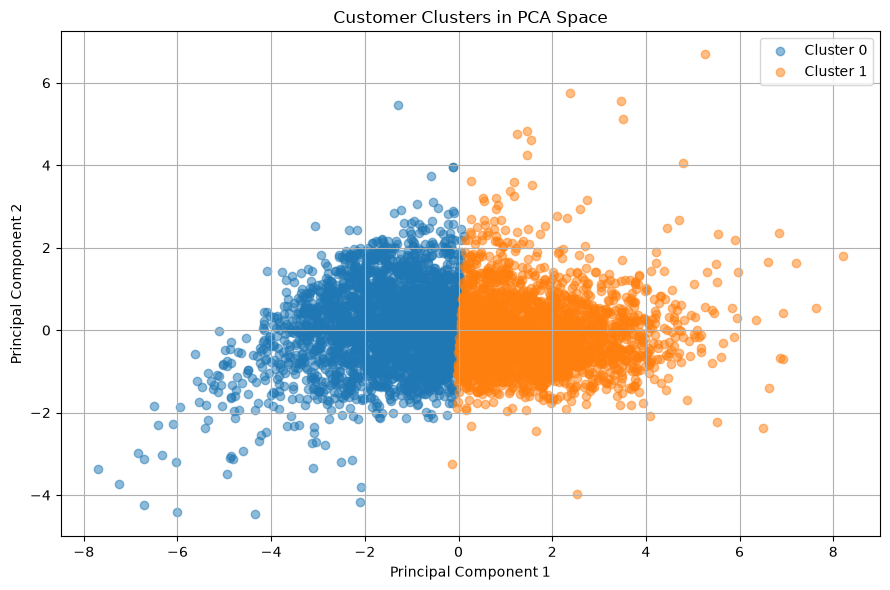

In [26]:
plt.figure(figsize=(9, 6))

for cluster in sorted(customer_clustered["Cluster"].unique()):
    mask = customer_clustered["Cluster"] == cluster

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.5
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Clusters in PCA Space")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = customer_clustered["Cluster"].values

pca_centroids = (
    pca_df
    .groupby("Cluster")[["PC1", "PC2"]]
    .mean()
)

print("===== PCA CLUSTER CENTROIDS =====")

display(pca_centroids.round(3))

===== PCA CLUSTER CENTROIDS =====


,PC1,PC2
Cluster,,
0,-1.593,0.090
1,1.640,-0.093


In [28]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Save algorithm comparison
algorithm_comparison.to_csv(
    output_dir / "clustering_algorithm_comparison.csv",
    index=False
)

# Save K-Means results for different K values
kmeans_results.to_csv(
    output_dir / "kmeans_k_comparison.csv",
    index=False
)

# Save cluster contribution
cluster_contribution.to_csv(
    output_dir / "cluster_business_contribution.csv"
)

# Save final customer cluster assignments
customer_clustered.to_csv(
    output_dir / "customer_clusters.csv",
    index=False
)

print("===== EXPERIMENT RESULTS SAVED =====")
print("Saved:")
print("- clustering_algorithm_comparison.csv")
print("- kmeans_k_comparison.csv")
print("- cluster_business_contribution.csv")
print("- customer_clusters.csv")

===== EXPERIMENT RESULTS SAVED =====
Saved:
- clustering_algorithm_comparison.csv
- kmeans_k_comparison.csv
- cluster_business_contribution.csv
- customer_clusters.csv


# Conclusion

## Objective

This notebook evaluated multiple clustering algorithms and different cluster configurations to identify a suitable customer segmentation approach.

The engineered customer feature matrix contained **5,350 customers and 6 standardized features**:

* Recency
* Frequency
* Monetary
* Total Quantity
* Unique Products
* Average Order Value

The evaluated algorithms were:

* K-Means
* Agglomerative Clustering
* Gaussian Mixture Model (GMM)
* DBSCAN

---

## 1. K-Means Experiments

K-Means was evaluated for cluster counts from **K=2 to K=10**.

The best configuration was:

**K-Means with K=2**

Results:

* Silhouette Score: **0.3632**
* Davies-Bouldin Index: **1.0260**
* Calinski-Harabasz Score: **4151.84**

K=2 produced the strongest overall clustering quality among the tested K-Means configurations.

The clusters were also highly balanced:

* Cluster 0: **2,714 customers (50.73%)**
* Cluster 1: **2,636 customers (49.27%)**

---

## 2. Algorithm Comparison

At their strongest tested configurations, K-Means K=2 outperformed the other clustering algorithms.

| Algorithm        | Configuration | Silhouette | Davies-Bouldin | Calinski-Harabasz |
| ---------------- | ------------- | ---------: | -------------: | ----------------: |
| **K-Means**      | **K=2**       | **0.3632** |     **1.0260** |       **4151.84** |
| Agglomerative    | K=2           |     0.3455 |         1.0708 |           3632.32 |
| Gaussian Mixture | K=2           |     0.3061 |         1.1608 |           3104.39 |
| DBSCAN           | eps=0.5       |     0.1713 |         2.9180 |            804.75 |

Therefore, **K-Means with K=2 was selected as the strongest clustering configuration for further evaluation.**

---

## 3. Cluster Profiles

The customer profiles were examined using the original, untransformed features.

### Cluster 0 — Inactive / Low-Value Customers

Median characteristics:

* Recency: **326 days**
* Frequency: **1 order**
* Monetary: **334.22**
* Total Quantity: **183.5**
* Unique Products: **20**
* Average Order Value: **197.68**

These customers purchase infrequently, have not purchased recently, and generate relatively low revenue.

### Cluster 1 — Active / High-Value Customers

Median characteristics:

* Recency: **37 days**
* Frequency: **7 orders**
* Monetary: **2,182.70**
* Total Quantity: **1,305.5**
* Unique Products: **101.5**
* Average Order Value: **337.72**

These customers purchase more recently, place more orders, spend substantially more, purchase larger quantities, and purchase a wider variety of products.

---

## 4. Relative Cluster Profiles

The cluster profiles were also compared against the overall customer median.

Cluster 0 showed:

* **3.31×** the overall median Recency
* **0.33×** the overall median Frequency
* **0.40×** the overall median Monetary value
* **0.40×** the overall median Quantity
* **0.45×** the overall median Product diversity
* **0.73×** the overall median Average Order Value

Cluster 1 showed:

* **0.38×** the overall median Recency
* **2.33×** the overall median Frequency
* **2.63×** the overall median Monetary value
* **2.81×** the overall median Quantity
* **2.31×** the overall median Product diversity
* **1.25×** the overall median Average Order Value

This confirms a clear behavioral difference between the two customer groups.

---

## 5. Business Contribution

The two clusters contained almost the same number of customers, but their business contribution was dramatically different.

| Metric         | Cluster 0 |  Cluster 1 |
| -------------- | --------: | ---------: |
| Customer Share |    50.73% |     49.27% |
| Revenue Share  | **7.65%** | **92.35%** |
| Quantity Share |     7.27% | **92.73%** |
| Order Share    |    15.04% | **84.96%** |

This indicates that approximately half of the customer base is responsible for more than **92% of total revenue** within the analyzed dataset.

---

## 6. Customer Value

Average revenue per customer:

* Cluster 0: **405.61**
* Cluster 1: **5,041.12**

Cluster 1 therefore generates approximately **12.4× more revenue per customer** than Cluster 0.

Average orders per customer:

* Cluster 0: **1.86**
* Cluster 1: **10.81**

Cluster 1 customers place approximately **5.8× more orders per customer**.

These differences demonstrate that the clusters have substantial practical business meaning rather than being separated only according to mathematical clustering metrics.

---

## 7. PCA Visualization

PCA was used only for visualization.

The first two principal components explained:

* PC1: **67.30%**
* PC2: **15.46%**
* Total: **82.76%**

The PCA visualization showed the two clusters occupying clearly separated regions of the feature space.

The average PCA positions were:

| Cluster |    PC1 |    PC2 |
| ------- | -----: | -----: |
| 0       | -1.593 |  0.090 |
| 1       |  1.640 | -0.093 |

The separation occurred primarily along **PC1**, which explains most of the variance in the data.

PCA was not used as a replacement for the original feature matrix. The clustering model was trained using all six engineered and standardized customer features.

---

## 8. DBSCAN Evaluation

DBSCAN was also evaluated using multiple epsilon values.

The results showed that DBSCAN was not well suited to the current customer feature representation.

At lower epsilon values, DBSCAN produced a large number of noise points and poor clustering quality. At higher epsilon values, the algorithm progressively collapsed into a single cluster.

Therefore, DBSCAN was not selected for the final customer segmentation model.

---

## 9. Final Experiment Conclusion

Based on the combination of:

* Clustering evaluation metrics
* Cluster balance
* Customer behavioral profiles
* Business contribution
* Revenue per customer
* PCA visualization

**K-Means with K=2 is the strongest candidate for the final customer segmentation model.**

The resulting segments can be interpreted as:

**Cluster 0 → Inactive / Low-Value Customers**

**Cluster 1 → Active / High-Value Customers**

However, the final production model has **not yet been finalized**. The next notebook will perform the final model-selection process, validate the chosen configuration, and prepare the model and preprocessing components for the production MLOps pipeline.

---

## Output Files

The following experiment artifacts were generated:

* `clustering_algorithm_comparison.csv`
* `kmeans_k_comparison.csv`
* `cluster_business_contribution.csv`
* `customer_clusters.csv`

These artifacts will be used in the next stage of the project.

---

## Next Step

**Notebook 4 — Final Model Selection**

The next notebook will focus on selecting and validating the final clustering model before moving into the production MLOps implementation.
